In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import chi2_contingency
from scipy.stats.contingency import association  # Cramer's V

In [2]:
df_demo = pd.read_csv("https://raw.githubusercontent.com/data-bootcamp-v4/lessons/refs/heads/main/5_6_eda_inf_stats_tableau/project/files_for_project/df_final_demo.txt")

In [3]:
df_experiment = pd.read_csv("https://raw.githubusercontent.com/data-bootcamp-v4/lessons/refs/heads/main/5_6_eda_inf_stats_tableau/project/files_for_project/df_final_experiment_clients.txt")

In [4]:
df_demo.head()

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth
0,836976,6.0,73.0,60.5,U,2.0,45105.30,6.0,9.0
1,2304905,7.0,94.0,58.0,U,2.0,110860.30,6.0,9.0
2,1439522,5.0,64.0,32.0,U,2.0,52467.79,6.0,9.0
3,1562045,16.0,198.0,49.0,M,2.0,67454.65,3.0,6.0
4,5126305,12.0,145.0,33.0,F,2.0,103671.75,0.0,3.0


- Null values and duplicates for both datasets

In [5]:
df_demo.isna().sum()

client_id            0
clnt_tenure_yr      14
clnt_tenure_mnth    14
clnt_age            15
gendr               14
num_accts           14
bal                 14
calls_6_mnth        14
logons_6_mnth       14
dtype: int64

In [6]:
df_demo = df_demo.dropna()

In [7]:
df_demo.isna().sum()

client_id           0
clnt_tenure_yr      0
clnt_tenure_mnth    0
clnt_age            0
gendr               0
num_accts           0
bal                 0
calls_6_mnth        0
logons_6_mnth       0
dtype: int64

In [8]:
df_demo.duplicated().sum()

np.int64(0)

In [9]:
df_experiment.isna().sum()

client_id        0
Variation    20109
dtype: int64

In [10]:
df_experiment.duplicated().sum()

np.int64(0)

In [11]:
# Drop all the null values from "Variation" because they are not relevant for the analysis 
df_experiment.dropna(axis = 0, inplace=True)

- Merge both tables to know which client_id corresponds to "Test"  or "Control"

In [12]:
df_clients = pd.merge(df_demo, df_experiment, on = "client_id")
df_clients.head() 

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth,Variation
0,836976,6.0,73.0,60.5,U,2.0,45105.30,6.0,9.0,Test
1,2304905,7.0,94.0,58.0,U,2.0,110860.30,6.0,9.0,Control
2,1439522,5.0,64.0,32.0,U,2.0,52467.79,6.0,9.0,Test
3,1562045,16.0,198.0,49.0,M,2.0,67454.65,3.0,6.0,Test
4,5126305,12.0,145.0,33.0,F,2.0,103671.75,0.0,3.0,Control


In [13]:
df_clients.isna().sum()

client_id           0
clnt_tenure_yr      0
clnt_tenure_mnth    0
clnt_age            0
gendr               0
num_accts           0
bal                 0
calls_6_mnth        0
logons_6_mnth       0
Variation           0
dtype: int64

In [14]:
df_clients.duplicated().sum()

np.int64(0)

### Concat 2 footprint datasets 

In [15]:
df_footprint1 = pd.read_csv("https://raw.githubusercontent.com/data-bootcamp-v4/lessons/refs/heads/main/5_6_eda_inf_stats_tableau/project/files_for_project/df_final_web_data_pt_1.txt")
df_footprint2 = pd.read_csv("https://raw.githubusercontent.com/data-bootcamp-v4/lessons/refs/heads/main/5_6_eda_inf_stats_tableau/project/files_for_project/df_final_web_data_pt_2.txt")


In [16]:
# Combining 2 footprint datasets 

df_footprint = pd.concat([df_footprint1, df_footprint2], axis = 0)
df_footprint

,client_id,visitor_id,visit_id,process_step,date_time
0,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:27:07
1,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:26:51
2,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:19:22
3,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:19:13
4,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:18:04
...,...,...,...,...,...
412259,9668240,388766751_9038881013,922267647_3096648104_968866,start,2017-05-24 18:46:10
412260,9668240,388766751_9038881013,922267647_3096648104_968866,start,2017-05-24 18:45:29
412261,9668240,388766751_9038881013,922267647_3096648104_968866,step_1,2017-05-24 18:44:51
412262,9668240,388766751_9038881013,922267647_3096648104_968866,start,2017-05-24 18:44:34


- Check nulls and duplicates

In [17]:
df_footprint.isna().sum()

client_id       0
visitor_id      0
visit_id        0
process_step    0
date_time       0
dtype: int64

In [18]:
df_footprint.duplicated().sum()

np.int64(10764)

In [19]:
# Show duplicates 

df_footprint[df_footprint.duplicated(keep=False)]

,client_id,visitor_id,visit_id,process_step,date_time
364,9358626,148475529_63668223960,223297395_36250329195_832161,start,2017-04-28 12:27:28
365,9358626,148475529_63668223960,223297395_36250329195_832161,start,2017-04-28 12:27:28
367,5376894,622509328_44408201172,688984457_43441834354_912755,start,2017-04-28 14:20:01
368,5376894,622509328_44408201172,688984457_43441834354_912755,start,2017-04-28 14:20:01
382,438567,923318467_50708963627,330543236_29863358529_771432,start,2017-04-28 02:52:29
...,...,...,...,...,...
412165,4408245,14058946_73585431797,994148957_84373994761_991865,start,2017-06-06 09:09:44
412166,4408245,14058946_73585431797,994148957_84373994761_991865,start,2017-06-06 08:51:16
412167,4408245,14058946_73585431797,994148957_84373994761_991865,start,2017-06-06 08:51:16
412216,3897324,80177429_24869309091,149796456_64325617570_112561,start,2017-05-04 08:21:30


In [20]:
df_footprint.drop_duplicates(inplace=True)
df_footprint.dropna(axis = 0, inplace=True)

Separate df_clients by Variation ("Test" or "Control") 

- Control Group: Clients interacted with Vanguard's traditional online process.
- Test Group: Clients experienced the new, spruced-up digital interface.

In [21]:
# Separate the df_clients table in 2 different tables according to the variation (Test or Control)

test_df = df_clients[df_clients["Variation"] == "Test"]
control_df = df_clients[df_clients["Variation"] == "Control"]

In [22]:
test_df.head()

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth,Variation
0,836976,6.0,73.0,60.5,U,2.0,45105.30,6.0,9.0,Test
2,1439522,5.0,64.0,32.0,U,2.0,52467.79,6.0,9.0,Test
3,1562045,16.0,198.0,49.0,M,2.0,67454.65,3.0,6.0,Test
7,388801,30.0,361.0,57.5,M,5.0,522498.72,1.0,4.0,Test
9,8198645,15.0,189.0,54.5,F,2.0,382303.83,6.0,9.0,Test


In [23]:
control_df.head()

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth,Variation
1,2304905,7.0,94.0,58.0,U,2.0,110860.30,6.0,9.0,Control
4,5126305,12.0,145.0,33.0,F,2.0,103671.75,0.0,3.0,Control
5,3727881,5.0,71.0,30.5,U,2.0,23915.60,0.0,3.0,Control
6,272934,5.0,66.0,58.5,U,2.0,27021.42,2.0,5.0,Control
8,285619,30.0,369.0,67.5,M,2.0,299388.72,3.0,6.0,Control


In [24]:
df_clients["gendr"].value_counts()

gendr
U    17280
M    16947
F    16258
X        2
Name: count, dtype: int64

In [25]:
df_clients.groupby("Variation")["gendr"].value_counts()

Variation  gendr
Control    U        8014
           M        7970
           F        7542
Test       U        9266
           M        8977
           F        8716
           X           2
Name: count, dtype: int64

In [26]:
df_clients["Variation"].value_counts()

Variation
Test       26961
Control    23526
Name: count, dtype: int64

In [27]:
df_footprint["process_step"].value_counts()

process_step
start      234999
step_1     162797
step_2     132750
step_3     111589
confirm    102506
Name: count, dtype: int64

### Client behavior analysis

- clnt_tenure_yr: Represents how long the client has been with Vanguard, measured in years.
- clnt_tenure_mnth: Further breaks down the client's tenure with Vanguard in months.
- clnt_age: Indicates the age of the client.
- bal: Gives the total balance spread across all accounts for a particular client.
- calls_6_mnth: Records the number of times the client reached out over a call in the past six months.
- logons_6_mnth: Reflects the frequency with which the client logged onto Vanguard's platform over the last six months.

In [28]:
df_clients.head()

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth,Variation
0,836976,6.0,73.0,60.5,U,2.0,45105.30,6.0,9.0,Test
1,2304905,7.0,94.0,58.0,U,2.0,110860.30,6.0,9.0,Control
2,1439522,5.0,64.0,32.0,U,2.0,52467.79,6.0,9.0,Test
3,1562045,16.0,198.0,49.0,M,2.0,67454.65,3.0,6.0,Test
4,5126305,12.0,145.0,33.0,F,2.0,103671.75,0.0,3.0,Control


In [29]:
# Exploring age 

df_clients["clnt_age"].describe()

count    50487.000000
mean        47.319795
std         15.518616
min         17.000000
25%         33.500000
50%         48.000000
75%         59.500000
max         96.000000
Name: clnt_age, dtype: float64

In [30]:
# Top 10 customer ages 

top_age = pd.crosstab(index=df_clients["clnt_age"], columns = "Count").sort_values(by= "Count", ascending=False).head(10)
top_age

col_0,Count
clnt_age,
58.5,621
59.5,607
28.5,597
57.5,594
52.5,593
31.5,593
61.5,590
30.5,588
27.5,588


<Axes: xlabel='clnt_age', ylabel='Count'>

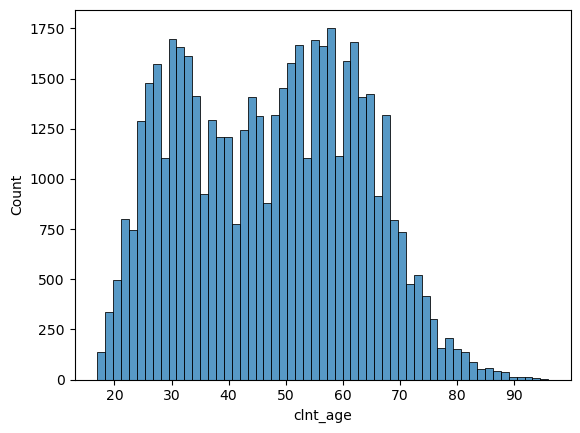

In [31]:
sns.histplot(df_clients["clnt_age"])

In [32]:
# Exploring gender distribution  

gender_distribution = pd.crosstab(index = df_clients["gendr"], columns = "Count")
gender_distribution

col_0,Count
gendr,
F,16258
M,16947
U,17280
X,2


In [33]:
# Calculate the mean value of the selected variables based by gender 

df_by_gender = df_clients.groupby("gendr")[["clnt_tenure_yr", "clnt_tenure_mnth", "clnt_age", "bal", "calls_6_mnth", "logons_6_mnth"]].mean()
df_by_gender 

,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,bal,calls_6_mnth,logons_6_mnth
gendr,,,,,,
F,14.771928,183.175114,50.423730,139082.033293,2.799176,5.850228
M,14.860211,184.120847,49.495810,212772.560084,3.427273,6.462914
U,6.680093,86.543113,42.267014,97311.649729,3.042361,6.072106
X,10.000000,124.500000,33.000000,28408.845000,3.500000,6.500000


In [34]:
# Any big differences between control vs test groups 

df_clients.groupby("Variation")[["clnt_tenure_yr", "clnt_tenure_mnth", "clnt_age", "bal", "calls_6_mnth", "logons_6_mnth"]].mean()


,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,bal,calls_6_mnth,logons_6_mnth
Variation,,,,,,
Control,12.087860,151.062102,47.498427,150151.900186,3.129176,6.166242
Test,11.982901,149.852899,47.163922,148962.605032,3.061941,6.101851


In [35]:
# Explore client tenure in years
df_clients["clnt_tenure_yr"].describe()

count    50487.000000
mean        12.031810
std          6.860326
min          2.000000
25%          6.000000
50%         11.000000
75%         16.000000
max         55.000000
Name: clnt_tenure_yr, dtype: float64

In [36]:
# Top 10 customer tenure (years) 

top_tenuer_years = pd.crosstab(index=df_clients["clnt_tenure_yr"], columns = "Count").sort_values(by= "Count", ascending=False).head(10)
top_tenuer_years

col_0,Count
clnt_tenure_yr,
6.0,5063
5.0,4950
7.0,3572
4.0,3381
15.0,3278
8.0,2919
14.0,2640
13.0,2586
12.0,2553


<Axes: xlabel='clnt_tenure_yr', ylabel='Count'>

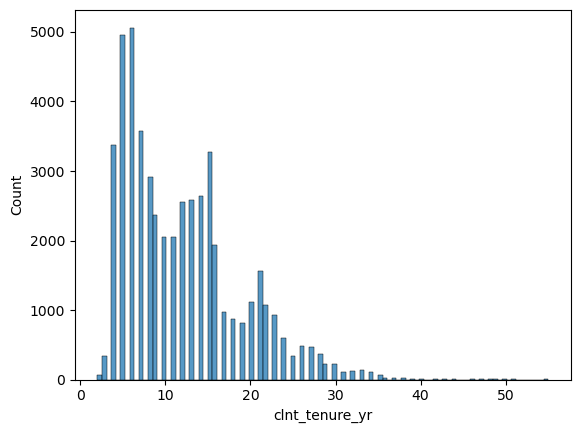

In [37]:
# Check distribution of tenuer(year)

sns.histplot(df_clients["clnt_tenure_yr"])

<Axes: xlabel='clnt_tenure_mnth', ylabel='Count'>

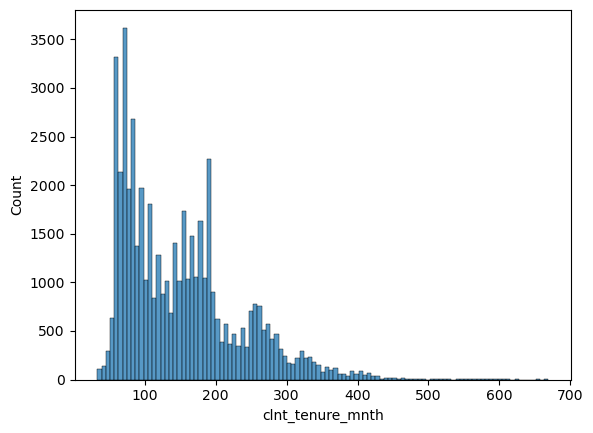

In [38]:
# Check distribution of tenuer(month)

sns.histplot(df_clients["clnt_tenure_mnth"])

In [39]:
# Client Behavior Analysis: Age & Tenure
# ----------------------------------------
# Age: Mean (47.3) and median (48.0) are nearly identical, indicating a fairly
# balanced distribution rather than one skewed by outliers. The middle 50% of
# clients fall between 33.5 and 59.5 years old (std = 15.5).
# --- Primary clients are middle-aged, skewing toward older-middle-age... 
# not a young, first-time-app-user demographic.

# Tenure: Mean (12.0 yrs) and median (11.0 yrs) are also closely aligned.
# The middle 50% of clients have been with Vanguard between 6 and 16 years,
# with a minimum tenure of 2 years (virtually no brand-new clients in this sample).
# --- Primary clients are long-standing, not new. This is an established... 
# client base engaging with a legacy platform, not first-time users testing out Vanguard.

In [40]:
# 1. How digitally engaged are clients?

In [41]:
df_clients["logons_6_mnth"].describe()

count    50487.000000
mean         6.131856
std          2.175441
min          3.000000
25%          4.000000
50%          6.000000
75%          8.000000
max          9.000000
Name: logons_6_mnth, dtype: float64

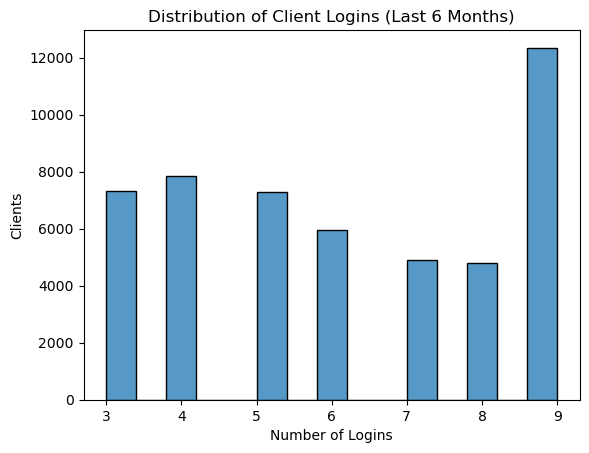

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df_clients["logons_6_mnth"], bins=15)
plt.title("Distribution of Client Logins (Last 6 Months)")
plt.xlabel("Number of Logins")
plt.ylabel("Clients")
plt.show()

In [43]:
# Any differnce between the test and control groups? 

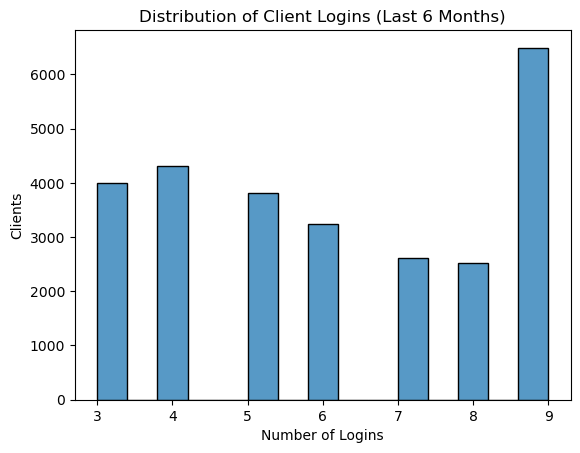

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(test_df["logons_6_mnth"], bins=15)
plt.title("Distribution of Client Logins (Last 6 Months)")
plt.xlabel("Number of Logins")
plt.ylabel("Clients")
plt.show()

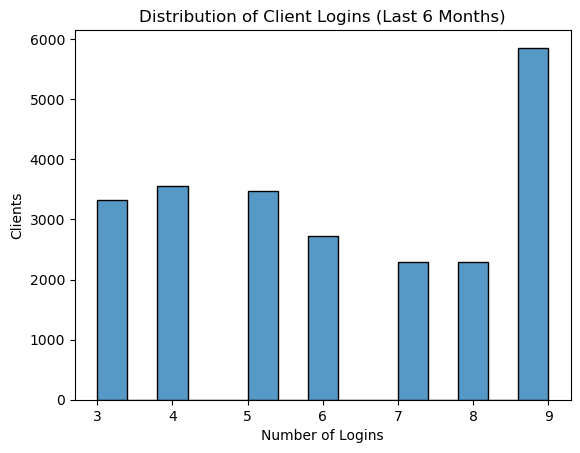

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(control_df["logons_6_mnth"], bins=15)
plt.title("Distribution of Client Logins (Last 6 Months)")
plt.xlabel("Number of Logins")
plt.ylabel("Clients")
plt.show()

In [46]:
# Correlation between age and no. of logins

In [47]:
df_clients[["clnt_age","logons_6_mnth"]].corr()

,clnt_age,logons_6_mnth
clnt_age,1.00000,0.05664
logons_6_mnth,0.05664,1.00000


In [48]:
df_clients[["clnt_tenure_yr","logons_6_mnth"]].corr()

,clnt_tenure_yr,logons_6_mnth
clnt_tenure_yr,1.000000,0.053017
logons_6_mnth,0.053017,1.000000


In [49]:
# Client age and tenure show virtually no correlation with the number of logins over the past six months 
# (r = 0.06 and r = 0.05, respectively). This suggests that digital engagement is relatively consistent 
# across different age groups and client tenures.

In [50]:
# 2. How often do clients contact customer support?

In [51]:
df_clients["calls_6_mnth"].describe()

count    50487.000000
mean         3.093272
std          2.188009
min          0.000000
25%          1.000000
50%          3.000000
75%          5.000000
max          6.000000
Name: calls_6_mnth, dtype: float64

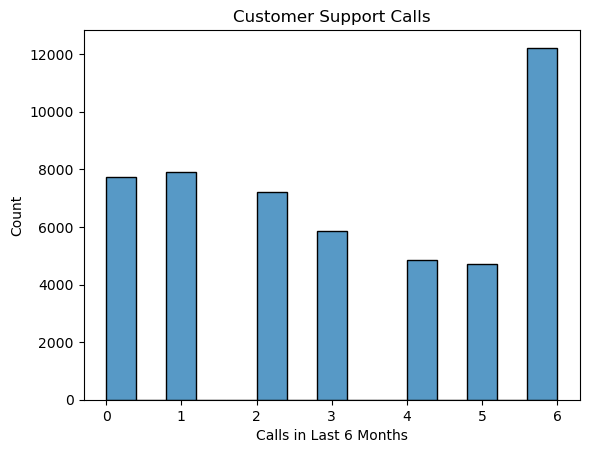

In [52]:
sns.histplot(df_clients["calls_6_mnth"], bins=15)

plt.title("Customer Support Calls")
plt.xlabel("Calls in Last 6 Months")
plt.show()

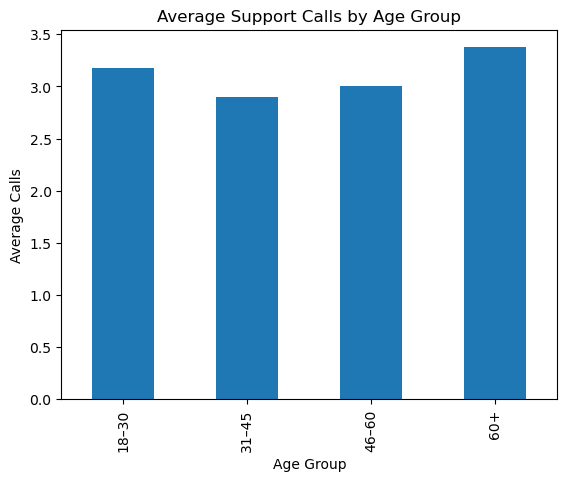

In [53]:
df_clients["age_group"] = pd.cut(
    df_clients["clnt_age"],
    bins=[18, 30, 45, 60, 100],
    labels=["18–30", "31–45", "46–60", "60+"],
    include_lowest=True
)

avg_calls = (
    df_clients
    .groupby("age_group", observed=True)["calls_6_mnth"]
    .mean()
)

avg_calls.plot(kind="bar")

plt.title("Average Support Calls by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Average Calls")
plt.show()

In [54]:
# Correlation between age and number of calls

In [55]:
df_clients[["clnt_age","calls_6_mnth"]].corr()

,clnt_age,calls_6_mnth
clnt_age,1.00000,0.04778
calls_6_mnth,0.04778,1.00000


In [56]:
# 3. Are digital engagement and support calls related?

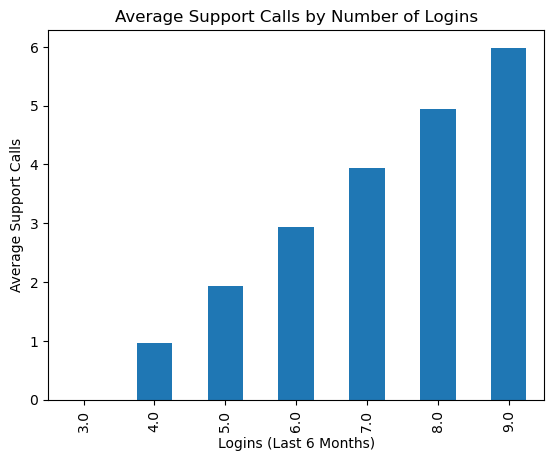

In [57]:
avg_calls = df_clients.groupby("logons_6_mnth")["calls_6_mnth"].mean()

avg_calls.plot(kind="bar")

plt.title("Average Support Calls by Number of Logins")
plt.xlabel("Logins (Last 6 Months)")
plt.ylabel("Average Support Calls")
plt.show()

In [58]:
df_clients[["logons_6_mnth","calls_6_mnth"]].corr()

,logons_6_mnth,calls_6_mnth
logons_6_mnth,1.000000,0.994447
calls_6_mnth,0.994447,1.000000


In [59]:
pd.crosstab(
    df_clients["logons_6_mnth"],
    df_clients["calls_6_mnth"]
)

calls_6_mnth,0.0,1.0,2.0,3.0,4.0,5.0,6.0
logons_6_mnth,,,,,,,
3.0,7311,0,0,0,0,0,0
4.0,347,7508,0,0,0,0,0
5.0,53,339,6891,0,0,0,0
6.0,10,48,279,5628,0,0,0
7.0,6,9,34,199,4665,0,0
8.0,4,2,9,24,164,4607,0
9.0,1,2,2,2,18,100,12225


In [60]:
# Conclusion: Clients who logged in more also almost always made more support calls.

In [61]:
# 4. Do wealthier clients behave differently?

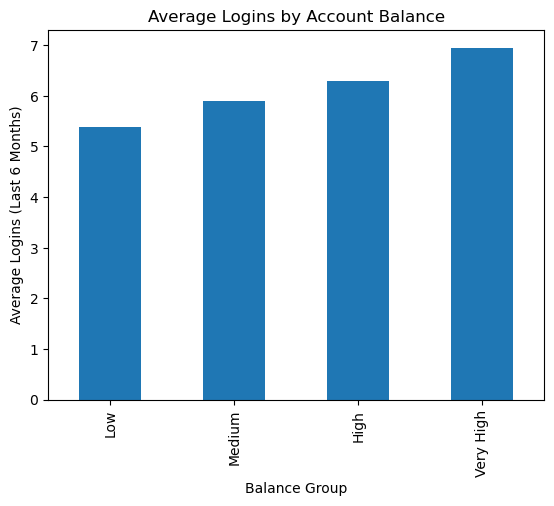

In [62]:
df_clients["balance_group"] = pd.qcut(
    df_clients["bal"],
    q=4,
    labels=["Low", "Medium", "High", "Very High"]
)

avg_logins = (
    df_clients
    .groupby("balance_group", observed=True)["logons_6_mnth"]
    .mean()
)

avg_logins.plot(kind="bar")

plt.title("Average Logins by Account Balance")
plt.xlabel("Balance Group")
plt.ylabel("Average Logins (Last 6 Months)")
plt.show()

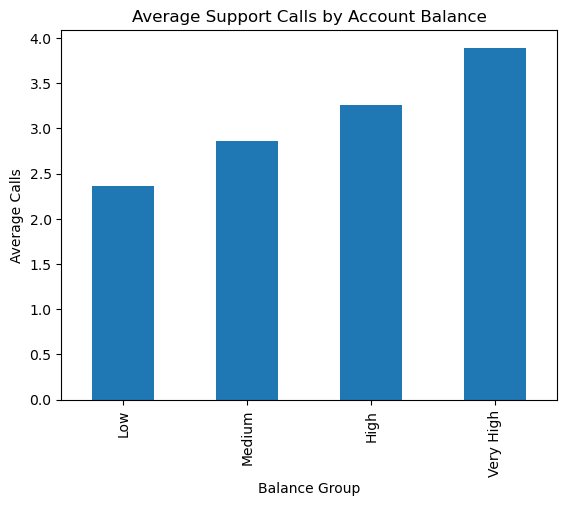

In [63]:
df_clients["balance_group"] = pd.qcut(
    df_clients["bal"],
    q=4,
    labels=["Low", "Medium", "High", "Very High"]
)

avg_calls = df_clients.groupby("balance_group", observed=True)["calls_6_mnth"].mean()

avg_calls.plot(kind="bar")

plt.title("Average Support Calls by Account Balance")
plt.xlabel("Balance Group")
plt.ylabel("Average Calls")
plt.show()

In [64]:
df_clients[["bal","logons_6_mnth","calls_6_mnth"]].corr()

,bal,logons_6_mnth,calls_6_mnth
bal,1.000000,0.175321,0.168390
logons_6_mnth,0.175321,1.000000,0.994447
calls_6_mnth,0.168390,0.994447,1.000000


In [65]:
# 5. Does product ownership influence engagement?

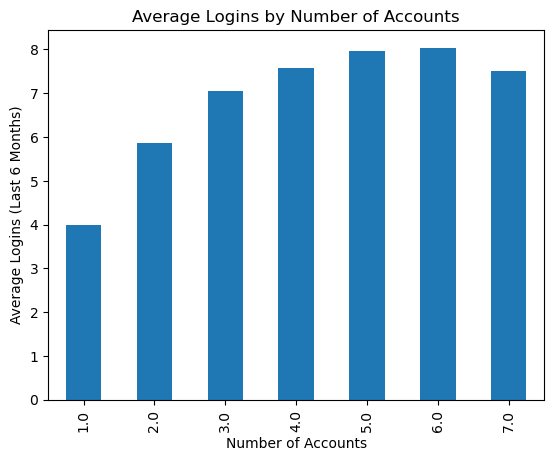

In [66]:
avg_logons = df_clients.groupby("num_accts")["logons_6_mnth"].mean()

avg_logons.plot(kind="bar")

plt.title("Average Logins by Number of Accounts")
plt.xlabel("Number of Accounts")
plt.ylabel("Average Logins (Last 6 Months)")
plt.show()

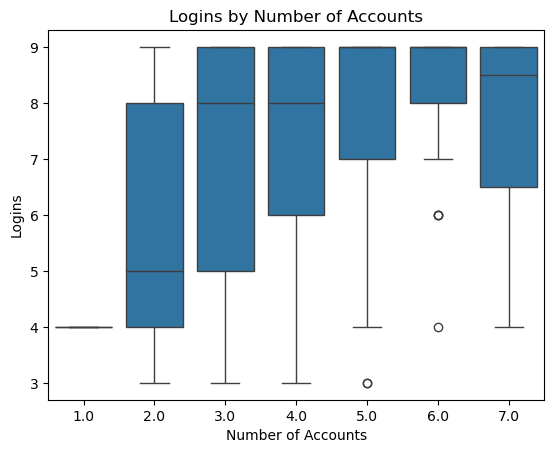

In [67]:
sns.boxplot(
    data=df_clients,
    x="num_accts",
    y="logons_6_mnth"
)

plt.title("Logins by Number of Accounts")
plt.xlabel("Number of Accounts")
plt.ylabel("Logins")
plt.show()

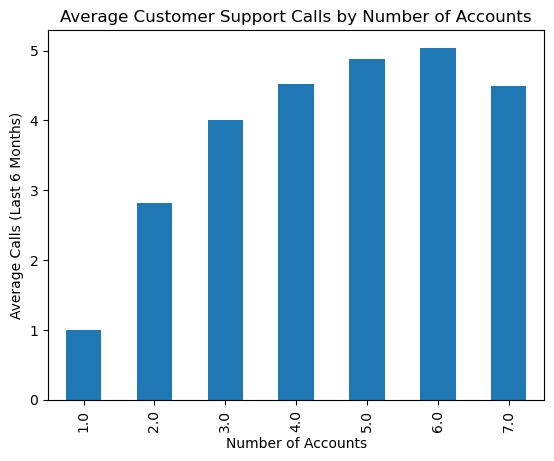

In [68]:
avg_calls = df_clients.groupby("num_accts")["calls_6_mnth"].mean()

avg_calls.plot(kind="bar")

plt.title("Average Customer Support Calls by Number of Accounts")
plt.xlabel("Number of Accounts")
plt.ylabel("Average Calls (Last 6 Months)")
plt.show()

In [69]:
df_clients.groupby("num_accts")[["logons_6_mnth","calls_6_mnth"]].mean()

,logons_6_mnth,calls_6_mnth
num_accts,,
1.0,4.000000,1.000000
2.0,5.856647,2.821047
3.0,7.049067,4.003130
4.0,7.581703,4.515457
5.0,7.970732,4.882927
6.0,8.043478,5.043478
7.0,7.500000,4.500000


In [70]:
# 6. Were Test and Control similarly engaged? Answer: yes.

In [71]:
df_clients.groupby("Variation")[["logons_6_mnth","calls_6_mnth"]].mean()

,logons_6_mnth,calls_6_mnth
Variation,,
Control,6.166242,3.129176
Test,6.101851,3.061941


In [72]:
df_clients.groupby("Variation")[["logons_6_mnth","calls_6_mnth"]].median()

,logons_6_mnth,calls_6_mnth
Variation,,
Control,6.0,3.0
Test,6.0,3.0


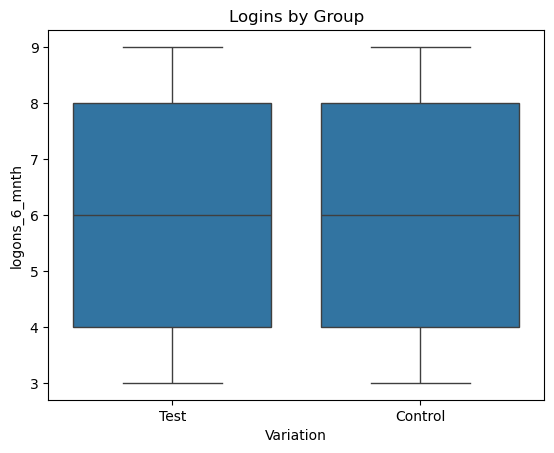

In [73]:
sns.boxplot(
    data=df_clients,
    x="Variation",
    y="logons_6_mnth"
)

plt.title("Logins by Group")
plt.show()

In [74]:
# Client Behaviour Analysis p II
# ----------------------------------------
# Clients are active users of Vanguard's digital platform, with most logging in between 3 and 9 times over the previous six months.
# Digital engagement is relatively consistent across age groups and client tenure, 
# suggesting that age and loyalty are not major drivers of login frequency.
# Clients with more accounts tend to log in more frequently and make more customer support calls, 
# indicating that customers with more complex portfolios interact more with Vanguard across multiple channels.
# Higher account balances do not show substantial differences in digital engagement, 
# suggesting that wealth alone is not a strong predictor of online activity.
# Login frequency and customer support calls are almost perfectly positively correlated (r ≈ 0.99). 
# More active digital users also tend to contact customer support more often, indicating that these variables 
# likely reflect overall client engagement rather than alternative communication channels.

## KPI & Metrics 

In [75]:
df_clients["gendr"].value_counts()

gendr
U    17280
M    16947
F    16258
X        2
Name: count, dtype: int64

In [76]:
df_clients["Variation"].value_counts()

Variation
Test       26961
Control    23526
Name: count, dtype: int64

In [77]:
df_footprint["process_step"].value_counts()

process_step
start      234999
step_1     162797
step_2     132750
step_3     111589
confirm    102506
Name: count, dtype: int64

In [78]:
# merging columns client_id and Variation to df_footprint (for kpi's)
df_footprint = df_footprint.merge(df_clients[["client_id", "Variation"]], on="client_id", how="left")
df_footprint.head()

,client_id,visitor_id,visit_id,process_step,date_time,Variation
0,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:27:07,Test
1,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:26:51,Test
2,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:19:22,Test
3,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:19:13,Test
4,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:18:04,Test


In [79]:
# counting the mismatches... checking if value is missing, output number = clients who weren't part of the formal experiment
df_footprint["Variation"].isna().sum()

np.int64(427518)

In [80]:
# comparing unique client counts
print(df_footprint["client_id"].nunique())
print(df_clients["client_id"].nunique())

120157
50487


In [81]:
# keeping only footprint rows tied to clients who were actually in the experiment, creating a copy
df_footprint_experiment = df_footprint[df_footprint["Variation"].notna()].copy()
df_footprint_experiment.shape

(317123, 6)

In [82]:
# Determine whether each visit reached the "confirm" step
# ----------------------------------------------------------------
# Group all footprint rows by visit_id, since one visit can have 
# multiple rows (one per action taken during that session).
# For each visit, check if "confirm" shows up anywhere in its 
# list of process_step values.
# Output: True/False per visit_id — True means that visit 
# completed the process, False means it dropped off somewhere earlier.

completed = df_footprint_experiment.groupby("visit_id")["process_step"].apply(lambda steps: "confirm" in steps.values)
completed.head()

visit_id
100012776_37918976071_457913     True
100019538_17884295066_43909      True
100022086_87870757897_149620     True
100030127_47967100085_936361    False
100037962_47432393712_705583    False
Name: process_step, dtype: bool

In [83]:
# bringing Variation back in, grouping by visit_id and Variation, .reset_index() to turn grouped result back into a table
completed = df_footprint_experiment.groupby(["visit_id", "Variation"])["process_step"].apply(lambda steps: "confirm" in steps.values)
completed = completed.reset_index()
completed.head()

,visit_id,Variation,process_step
0,100012776_37918976071_457913,Test,True
1,100019538_17884295066_43909,Test,True
2,100022086_87870757897_149620,Test,True
3,100030127_47967100085_936361,Control,False
4,100037962_47432393712_705583,Control,False


In [84]:
# renaming column name - process step to completed, old column name misleading
completed = completed.rename(columns={"process_step": "completed"})
completed.head()

,visit_id,Variation,completed
0,100012776_37918976071_457913,Test,True
1,100019538_17884295066_43909,Test,True
2,100022086_87870757897_149620,Test,True
3,100030127_47967100085_936361,Control,False
4,100037962_47432393712_705583,Control,False


In [85]:
# KPI rate - group by Variation and the average of completed column
completion_rate = completed.groupby("Variation")["completed"].mean()
completion_rate

Variation
Control    0.498400
Test       0.585232
Name: completed, dtype: float64

In [86]:
# comparing test and control - how many visits in each group (maybe this will be needed for presentation?)
completed.groupby("Variation")["completed"].count()

Variation
Control    32181
Test       37122
Name: completed, dtype: int64

In [87]:
# Completion Rate KPI
# ----------------------------------------------------------------
# Control: 49.8% completion rate 
# Test:    58.5% completion rate 
# --- The new design shows an 8.7 percentage point improvement 
# --- 17% better than the old design.

In [88]:
# sorting by date and time within each visit - earliest to latest, to calculate the time difference between rows
df_sorted = df_footprint_experiment.sort_values(by=["visit_id", "date_time"])

In [89]:
# confirming sorting is sequential now
df_sorted.head()

,client_id,visitor_id,visit_id,process_step,date_time,Variation
107971,3561384,451664975_1722933822,100012776_37918976071_457913,confirm,2017-04-26 13:22:17,Test
107970,3561384,451664975_1722933822,100012776_37918976071_457913,confirm,2017-04-26 13:23:09,Test
239141,7338123,612065484_94198474375,100019538_17884295066_43909,start,2017-04-09 16:20:56,Test
239140,7338123,612065484_94198474375,100019538_17884295066_43909,step_1,2017-04-09 16:21:12,Test
239139,7338123,612065484_94198474375,100019538_17884295066_43909,step_2,2017-04-09 16:21:21,Test


In [90]:
# converting date_time to an actual datetime type for calculations
df_footprint_experiment["date_time"] = pd.to_datetime(df_footprint_experiment["date_time"])
df_footprint_experiment["date_time"].dtype

dtype('<M8[ns]')

In [91]:
# calculate the time between rows, within each visit
df_sorted = df_footprint_experiment.sort_values(by=["visit_id", "date_time"])
df_sorted["time_spent"] = df_sorted.groupby("visit_id")["date_time"].diff()
df_sorted.head(10)

,client_id,visitor_id,visit_id,process_step,date_time,Variation,time_spent
107971,3561384,451664975_1722933822,100012776_37918976071_457913,confirm,2017-04-26 13:22:17,Test,NaT
107970,3561384,451664975_1722933822,100012776_37918976071_457913,confirm,2017-04-26 13:23:09,Test,0 days 00:00:52
239141,7338123,612065484_94198474375,100019538_17884295066_43909,start,2017-04-09 16:20:56,Test,NaT
239140,7338123,612065484_94198474375,100019538_17884295066_43909,step_1,2017-04-09 16:21:12,Test,0 days 00:00:16
239139,7338123,612065484_94198474375,100019538_17884295066_43909,step_2,2017-04-09 16:21:21,Test,0 days 00:00:09
239138,7338123,612065484_94198474375,100019538_17884295066_43909,step_1,2017-04-09 16:21:35,Test,0 days 00:00:14
239137,7338123,612065484_94198474375,100019538_17884295066_43909,step_1,2017-04-09 16:21:41,Test,0 days 00:00:06
239136,7338123,612065484_94198474375,100019538_17884295066_43909,start,2017-04-09 16:21:45,Test,0 days 00:00:04
239135,7338123,612065484_94198474375,100019538_17884295066_43909,start,2017-04-09 16:21:59,Test,0 days 00:00:14
239134,7338123,612065484_94198474375,100019538_17884295066_43909,step_1,2017-04-09 16:22:04,Test,0 days 00:00:05


In [92]:
# creates a new column "for each row, here's the step that the time_spent value on this row describes"
df_sorted["step_time_belongs_to"] = df_sorted.groupby("visit_id")["process_step"].shift(1)

In [93]:
# for the KPI, group by step_time_belongs_to and average time_spent
avg_time_per_step = df_sorted.groupby(["step_time_belongs_to", "Variation"])["time_spent"].mean()

In [94]:
# checking result
df_sorted.head(10)

,client_id,visitor_id,visit_id,process_step,date_time,Variation,time_spent,step_time_belongs_to
107971,3561384,451664975_1722933822,100012776_37918976071_457913,confirm,2017-04-26 13:22:17,Test,NaT,NaN
107970,3561384,451664975_1722933822,100012776_37918976071_457913,confirm,2017-04-26 13:23:09,Test,0 days 00:00:52,confirm
239141,7338123,612065484_94198474375,100019538_17884295066_43909,start,2017-04-09 16:20:56,Test,NaT,NaN
239140,7338123,612065484_94198474375,100019538_17884295066_43909,step_1,2017-04-09 16:21:12,Test,0 days 00:00:16,start
239139,7338123,612065484_94198474375,100019538_17884295066_43909,step_2,2017-04-09 16:21:21,Test,0 days 00:00:09,step_1
239138,7338123,612065484_94198474375,100019538_17884295066_43909,step_1,2017-04-09 16:21:35,Test,0 days 00:00:14,step_2
239137,7338123,612065484_94198474375,100019538_17884295066_43909,step_1,2017-04-09 16:21:41,Test,0 days 00:00:06,step_1
239136,7338123,612065484_94198474375,100019538_17884295066_43909,start,2017-04-09 16:21:45,Test,0 days 00:00:04,step_1
239135,7338123,612065484_94198474375,100019538_17884295066_43909,start,2017-04-09 16:21:59,Test,0 days 00:00:14,start
239134,7338123,612065484_94198474375,100019538_17884295066_43909,step_1,2017-04-09 16:22:04,Test,0 days 00:00:05,start


In [95]:
# the KPI - average time per step
avg_time_per_step = df_sorted.groupby(["step_time_belongs_to", "Variation"])["time_spent"].mean()
avg_time_per_step

step_time_belongs_to  Variation
confirm               Control     0 days 00:03:07.040374199
                      Test        0 days 00:04:07.563796804
start                 Control     0 days 00:01:06.814265319
                      Test        0 days 00:01:01.474345685
step_1                Control     0 days 00:00:50.505569211
                      Test        0 days 00:01:00.784859660
step_2                Control     0 days 00:01:32.029867939
                      Test        0 days 00:01:28.896547059
step_3                Control     0 days 00:02:17.206382873
                      Test        0 days 00:02:09.620668084
Name: time_spent, dtype: timedelta64[ns]

In [96]:
# Average Time Per Step KPI:
#----------------------------------------------------------------------------------
# start: Control 63s, Test 61s — basically a wash, no meaningful difference
# step_1: Control 50s, Test 61s — Test is actually slower here by about 10 seconds
# step_2: Control 92s, Test 89s — roughly the same, tiny edge to Test
# step_3: Control 135s, Test 129s — roughly the same, tiny edge to Test
# confirm: Control 170s, Test 240s — Test takes 70 seconds longer, a big gap

# What this means:
#---------------------------------------------------------------------------------
# The new design doesn't universally speed things up.
# Clients in Test actually spend more time on step 1 and noticeably more time in confirm compared to Control
# Only step 2 and step 3 show Test being marginally faster
# and those differences are small enough they might not even be meaningful once significant testing is run

#Why this matters:
#---------------------------------------------------------------------------------
# It's more nuanced than "new design = faster"
# The new UI may include more in context prompts/guidance, which could genuinely add time on certain steps, especially confirm
# where people might be double checking info because the interface is walking them through more carefully.
# That's not necessarily bad UX, just different.

In [97]:
# checking if multiple confirm entries could be inflating the confirm average artificially
df_sorted[df_sorted["process_step"] == "confirm"]["visit_id"].value_counts().head()

visit_id
155305468_93296256914_310722    11
820090283_58581376462_851669    10
888059775_41615184565_735869     9
834703874_81652602361_748606     9
50537501_11478756856_509628      9
Name: count, dtype: int64

In [98]:
# checking for timestamps - logging duplication confirmation
df_sorted[df_sorted["visit_id"] == "115772476_64303792531_611679"][["process_step", "date_time", "time_spent"]]

,process_step,date_time,time_spent
524397,start,2017-05-02 10:47:38,NaT
524396,step_1,2017-05-02 10:47:46,0 days 00:00:08
524395,step_2,2017-05-02 10:48:11,0 days 00:00:25
524394,step_3,2017-05-02 10:49:45,0 days 00:01:34
524393,confirm,2017-05-02 10:50:15,0 days 00:00:30
524369,confirm,2017-05-02 10:51:45,0 days 00:01:30


In [99]:
# deduplicating as one row per unique, collapsing into one
df_footprint_experiment = df_footprint_experiment.drop_duplicates(
    subset=["visit_id", "process_step", "date_time"]
)

In [100]:
# checking the total duplicates across the whole dataset
df_footprint_experiment.duplicated(subset=["visit_id", "process_step", "date_time"]).sum()

np.int64(0)

In [101]:
# deduplicate
df_footprint_experiment = df_footprint_experiment.drop_duplicates(
    subset=["visit_id", "process_step", "date_time"]
)

In [102]:
#quick check after deduplicating, dropped from 321,195
print(len(df_footprint_experiment))

317123


In [103]:
# Redo completion rate with clean data
completed = df_footprint_experiment.groupby(["visit_id", "Variation"])["process_step"].apply(lambda steps: "confirm" in steps.values)
completed = completed.reset_index()
completed = completed.rename(columns={"process_step": "completed"})

completion_rate = completed.groupby("Variation")["completed"].mean()
completion_rate

Variation
Control    0.498400
Test       0.585232
Name: completed, dtype: float64

In [104]:
# Redo Time spent on each step
df_sorted = df_footprint_experiment.sort_values(by=["visit_id", "date_time"])
df_sorted["time_spent"] = df_sorted.groupby("visit_id")["date_time"].diff()
df_sorted["step_time_belongs_to"] = df_sorted.groupby("visit_id")["process_step"].shift(1)

avg_time_per_step = df_sorted.groupby(["step_time_belongs_to", "Variation"])["time_spent"].mean()
avg_time_per_step

step_time_belongs_to  Variation
confirm               Control     0 days 00:03:07.040374199
                      Test        0 days 00:04:07.563796804
start                 Control     0 days 00:01:06.814265319
                      Test        0 days 00:01:01.474345685
step_1                Control     0 days 00:00:50.505569211
                      Test        0 days 00:01:00.784859660
step_2                Control     0 days 00:01:32.029867939
                      Test        0 days 00:01:28.896547059
step_3                Control     0 days 00:02:17.206382873
                      Test        0 days 00:02:09.620668084
Name: time_spent, dtype: timedelta64[ns]

In [105]:
# Cleaned data: Completion Rate and Average Time Per Step KPI:
#----------------------------------------------------------------------------------
# Completion Rate is identical as before: Control 49.8%, Test 58.5%
# Time spent per step: The confirm average went up, not down
# and Test is slower on step 1 and confirm, roughly even on start
# and marginally faster on step 2 and step 3

In [106]:
# Data quality check: duplicate logging events
# ----------------------------------------------------------------
# Found exact duplicate rows (same visit_id, process_step, date_time) 
# affecting 4,072 rows - likely a tracking/
# logging artifact, not real repeated user actions.
# Removed via drop_duplicates() before calculating time-based KPIs.
# Completion rate was unaffected (unchanged before/after), since it 
# only checks step presence, not row count.

In [107]:
# KPI 1: Completion Rate - Final
# ----------------------------------------------------------------
# proportion of visits that reached the "confirm" step
#
# RESULTS:
#   Control: 49.8% completion rate (n = 32,181 visits)
#   Test:    58.5% completion rate (n = 37,122 visits)
#
# INTERPRETATION:
#   The new design shows an 8.7 percentage point improvement 
#   17% better than the old design. This is a meaningful gap, not a marginal one supports the hypothesis that the
#   redesigned UI helped more clients finish the process.


# KPI 2: Time Spent on Each Step - Final
# ----------------------------------------------------------------
# average duration between arriving at one step and moving to the next
#
# RESULTS:
#   step_1:   Control 50s   | Test 61s   --- Test is SLOWER
#   step_2:   Control 92s   | Test 89s   --- roughly even
#   step_3:   Control 137s  | Test 130s  --- roughly even
#   confirm:  Control 187s  | Test 248s  --- Test is SLOWER
#
# INTERPRETATION:
#   The new design does NOT uniformly speed up the process. Test users spend more time on step_1 and confirm specifically, while
#   users spend more time on step_1 and confirm specifically, while step_2/step_3 show negligible differences. This complicates a 
#   simple "new design = faster" narrative — possible explanation: added in-context prompts/guidance in the redesign may increase
#   time spent on certain steps even while improving completion.
#   --- Worth exploring further in Experiment Evaluation section.

- Error rate 

In [108]:
df_footprint.drop_duplicates(inplace=True)
df_footprint.dropna(axis = 0, inplace=True)

In [109]:
df_footprint.isna().sum()

client_id       0
visitor_id      0
visit_id        0
process_step    0
date_time       0
Variation       0
dtype: int64

In [110]:
df_footprint.head()

,client_id,visitor_id,visit_id,process_step,date_time,Variation
0,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:27:07,Test
1,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:26:51,Test
2,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:19:22,Test
3,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:19:13,Test
4,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:18:04,Test


In [111]:
# Set correct step order 

step_order = {"start": 0,
              "step_1": 1, 
              "step_2": 2, 
              "step_3": 3, 
              "confirm": 4
              }

In [112]:
df_footprint2 = df_footprint.sort_values(["visitor_id", "date_time"]).reset_index(drop=True)


In [113]:
df_footprint2.head()

,client_id,visitor_id,visit_id,process_step,date_time,Variation
0,6265388,100019786_4272121951,703380671_89376183829_330646,start,2017-04-15 15:13:33,Test
1,6265388,100019786_4272121951,703380671_89376183829_330646,step_1,2017-04-15 15:13:46,Test
2,6265388,100019786_4272121951,703380671_89376183829_330646,step_2,2017-04-15 15:14:21,Test
3,6265388,100019786_4272121951,703380671_89376183829_330646,step_3,2017-04-15 15:15:50,Test
4,6265388,100019786_4272121951,703380671_89376183829_330646,confirm,2017-04-15 15:16:18,Test


In [114]:
# Create a new column showing the steps in numbers 

df_footprint2["step_number"] = df_footprint2["process_step"].map(step_order)

In [115]:
df_footprint2.head()

,client_id,visitor_id,visit_id,process_step,date_time,Variation,step_number
0,6265388,100019786_4272121951,703380671_89376183829_330646,start,2017-04-15 15:13:33,Test,0
1,6265388,100019786_4272121951,703380671_89376183829_330646,step_1,2017-04-15 15:13:46,Test,1
2,6265388,100019786_4272121951,703380671_89376183829_330646,step_2,2017-04-15 15:14:21,Test,2
3,6265388,100019786_4272121951,703380671_89376183829_330646,step_3,2017-04-15 15:15:50,Test,3
4,6265388,100019786_4272121951,703380671_89376183829_330646,confirm,2017-04-15 15:16:18,Test,4


In [116]:
df_footprint2.head()
df_footprint2.to_csv("my_df.csv", index=False)

In [117]:
# Create a new column showing the previous step for each visit_id

df_footprint2["prev_step"] = df_footprint2.groupby("visit_id")["step_number"].shift()

In [118]:
df_footprint2.head(8)

,client_id,visitor_id,visit_id,process_step,date_time,Variation,step_number,prev_step
0,6265388,100019786_4272121951,703380671_89376183829_330646,start,2017-04-15 15:13:33,Test,0,NaN
1,6265388,100019786_4272121951,703380671_89376183829_330646,step_1,2017-04-15 15:13:46,Test,1,0.0
2,6265388,100019786_4272121951,703380671_89376183829_330646,step_2,2017-04-15 15:14:21,Test,2,1.0
3,6265388,100019786_4272121951,703380671_89376183829_330646,step_3,2017-04-15 15:15:50,Test,3,2.0
4,6265388,100019786_4272121951,703380671_89376183829_330646,confirm,2017-04-15 15:16:18,Test,4,3.0
5,6265388,100019786_4272121951,703380671_89376183829_330646,confirm,2017-04-15 15:16:47,Test,4,4.0
6,2340487,100026388_52569174348,560716384_55516231568_734638,start,2017-06-09 18:37:47,Test,0,NaN
7,2340487,100026388_52569174348,560716384_55516231568_734638,start,2017-06-09 18:37:59,Test,0,0.0


In [119]:
# Create a column showing: if customer get back to the prev step or is in the same step -> is an error (True)

df_footprint2["is_error"] = df_footprint2["step_number"] <= df_footprint2["prev_step"]

In [120]:
df_footprint2.head(10)

,client_id,visitor_id,visit_id,process_step,date_time,Variation,step_number,prev_step,is_error
0,6265388,100019786_4272121951,703380671_89376183829_330646,start,2017-04-15 15:13:33,Test,0,NaN,False
1,6265388,100019786_4272121951,703380671_89376183829_330646,step_1,2017-04-15 15:13:46,Test,1,0.0,False
2,6265388,100019786_4272121951,703380671_89376183829_330646,step_2,2017-04-15 15:14:21,Test,2,1.0,False
3,6265388,100019786_4272121951,703380671_89376183829_330646,step_3,2017-04-15 15:15:50,Test,3,2.0,False
4,6265388,100019786_4272121951,703380671_89376183829_330646,confirm,2017-04-15 15:16:18,Test,4,3.0,False
5,6265388,100019786_4272121951,703380671_89376183829_330646,confirm,2017-04-15 15:16:47,Test,4,4.0,True
6,2340487,100026388_52569174348,560716384_55516231568_734638,start,2017-06-09 18:37:47,Test,0,NaN,False
7,2340487,100026388_52569174348,560716384_55516231568_734638,start,2017-06-09 18:37:59,Test,0,0.0,True
8,2340487,100026388_52569174348,560716384_55516231568_734638,step_1,2017-06-09 18:38:06,Test,1,0.0,False
9,2340487,100026388_52569174348,560716384_55516231568_734638,start,2017-06-09 18:38:41,Test,0,1.0,True


In [121]:
error_rate = df_footprint2["is_error"].mean()
error_rate 

np.float64(0.18517420685349217)

In [122]:
# Get proportion of number of errors by group. Overall proportion of events that are errors 

error_by_group = df_footprint2.groupby("Variation")["is_error"].mean().sort_values(ascending=False)
error_by_group 

Variation
Test       0.200163
Control    0.166327
Name: is_error, dtype: float64

In [123]:
# Test the difference's significance 

# H0: the error proportion is the same for Test and Control groups 
# H1: error proportion Test ≠ error proportion Control 


In [124]:
control = df_footprint2[df_footprint2["Variation"] == "Control"]
test = df_footprint2[df_footprint2["Variation"] == "Test"]

control_errors = control["is_error"].sum()
control_total = len(control)

test_errors = test["is_error"].sum()
test_total = len(test)

In [125]:
from statsmodels.stats.proportion import proportions_ztest

stat, pval = proportions_ztest(
    count=[test_errors, control_errors],
    nobs=[test_total, control_total]
)

print("Z-statistic:", stat)
print("p-value:", pval)

# p = 3.868571944206516e-131 which is below 0.05 hence rejecting H0. 

Z-statistic: 24.366578778850414
p-value: 3.868571944206516e-131


In [126]:
df_footprint2.tail()

,client_id,visitor_id,visit_id,process_step,date_time,Variation,step_number,prev_step,is_error
317118,7042750,999998529_89539814462,583327415_19513940564_488564,step_2,2017-04-12 11:55:05,Control,2,3.0,True
317119,7042750,999998529_89539814462,583327415_19513940564_488564,step_3,2017-04-12 11:55:13,Control,3,2.0,False
317120,7042750,999998529_89539814462,583327415_19513940564_488564,confirm,2017-04-12 12:04:47,Control,4,3.0,False
317121,7042750,999998529_89539814462,583327415_19513940564_488564,start,2017-04-12 12:09:29,Control,0,4.0,True
317122,7042750,999998529_89539814462,583327415_19513940564_488564,step_1,2017-04-12 12:09:47,Control,1,0.0,False


In [127]:
# Calculate the proportion of error rate for step by group: Divide number of errors/ total size of errors 

#Count how many times each step was visited (denominator)
visits_per_step = df_footprint2.groupby(['Variation', 'step_number']).size().rename('total_visits') 

# Find the rows where clients went backward 
went_back = df_footprint2[df_footprint2["step_number"] <= df_footprint2["prev_step"]]

# (numerator) get the size of above results 
backward_by_groups = went_back.groupby(["Variation", "prev_step"]).size().rename("backward_move") 

In [128]:
# Change labels for clarity. Change prev_step -> step_number 

backward_by_groups.index.set_names(["Variation", "step_number"], inplace=True)

In [129]:
backward_by_groups

Variation  step_number
Control    0.0             9657
           1.0             3678
           2.0             3005
           3.0             4995
           4.0             2031
Test       0.0            12201
           1.0             7980
           2.0             5363
           3.0             5620
           4.0             4193
Name: backward_move, dtype: int64

In [130]:
# make both series to df to be merged 
visits_per_step = visits_per_step.reset_index()
backward_by_groups = backward_by_groups.reset_index()

In [131]:
visits_per_step

,Variation,step_number,total_visits
0,Control,0,45361
1,Control,1,29533
2,Control,2,25764
3,Control,3,22495
4,Control,4,17329
5,Test,0,55753
6,Test,1,38651
7,Test,2,30888
8,Test,3,25755
9,Test,4,25594


In [132]:
backward_by_groups

,Variation,step_number,backward_move
0,Control,0.0,9657
1,Control,1.0,3678
2,Control,2.0,3005
3,Control,3.0,4995
4,Control,4.0,2031
5,Test,0.0,12201
6,Test,1.0,7980
7,Test,2.0,5363
8,Test,3.0,5620
9,Test,4.0,4193


In [133]:
# Prepare the df for the division 

table1 = pd.merge(visits_per_step, backward_by_groups, on = ["Variation", "step_number"], how= "left")
table1 = table1.fillna(0)
table1.head(20)

,Variation,step_number,total_visits,backward_move
0,Control,0,45361,9657
1,Control,1,29533,3678
2,Control,2,25764,3005
3,Control,3,22495,4995
4,Control,4,17329,2031
5,Test,0,55753,12201
6,Test,1,38651,7980
7,Test,2,30888,5363
8,Test,3,25755,5620
9,Test,4,25594,4193


In [134]:
table1["backward_move %"] = ((table1["backward_move"]/table1["total_visits"])*100).round(2)

In [135]:
table1

,Variation,step_number,total_visits,backward_move,backward_move %
0,Control,0,45361,9657,21.29
1,Control,1,29533,3678,12.45
2,Control,2,25764,3005,11.66
3,Control,3,22495,4995,22.20
4,Control,4,17329,2031,11.72
5,Test,0,55753,12201,21.88
6,Test,1,38651,7980,20.65
7,Test,2,30888,5363,17.36
8,Test,3,25755,5620,21.82
9,Test,4,25594,4193,16.38


In [136]:
table1.reset_index().pivot(index="step_number", columns="Variation", values = ["backward_move %"])

backward_move %       
Variation           Control   Test
step_number                       
0                     21.29  21.88
1                     12.45  20.65
2                     11.66  17.36
3                     22.20  21.82
4                     11.72  16.38

In [141]:
table1.to_csv(
    "table1_semicolon.csv",
    index=False,
    sep=";",              # matches Spanish locale default
    quoting=csv.QUOTE_ALL,
    encoding="utf-8"
)

In [137]:
pivot = table1.reset_index().pivot(index="step_number", columns="Variation", values = ["total_visits", "backward_move"])
pivot

total_visits        backward_move       
Variation        Control   Test       Control   Test
step_number                                         
0                  45361  55753          9657  12201
1                  29533  38651          3678   7980
2                  25764  30888          3005   5363
3                  22495  25755          4995   5620
4                  17329  25594          2031   4193

In [138]:
import pandas as pd
import csv


pivot.to_csv(
    "pivot_semicolon.csv",
    index=False,
    sep=";",              # matches Spanish locale default
    quoting=csv.QUOTE_ALL,
    encoding="utf-8"
)

In [139]:
# check significance 

# H₀: The error proportion (backward_move) is the same in the Test and Control groups.
# H₁: The error proportion is different in the Test and Control groups.

from statsmodels.stats.proportion import proportions_ztest 

for step in [0,1, 2, 3, 4]:

    c_count = pivot.loc[step, ('backward_move', 'Control')]
    c_nobs  = pivot.loc[step, ('total_visits', 'Control')]

    t_count = pivot.loc[step, ('backward_move', 'Test')]
    t_nobs  = pivot.loc[step, ('total_visits', 'Test')]

    stat, pval = proportions_ztest(
        count=[t_count, c_count],
        nobs=[t_nobs, c_nobs]
    )

    print(f"Step {step}: p-value = {pval}")
    if pval < 0.05: 
        print("Reject Ho")
    else: 
        print ("Failed to reject Ho")

Step 0: p-value = 0.02229661640588548
Reject Ho
Step 1: p-value = 2.0946927295536666e-174
Reject Ho
Step 2: p-value = 8.353599340286259e-81
Reject Ho
Step 3: p-value = 0.3098260606358738
Failed to reject Ho
Step 4: p-value = 2.6739665337814254e-41
Reject Ho


In [140]:
#  KPI 3: Error rates 
# ----------------------------------------------------------------
# If there's a step where users go back to a previous step, it may indicate confusion or an error. 
# Moving from a later step to an earlier one is considered as an error.
#
# RESULTS:
#   Control: 16.6% error rate. Most frequenty incorrect step: Step 1 --> customers going back from "step 1" to "start" 
#   Test:    20% error rate. Most frequent backward step: Step 1 --> customers going back from "step 1" to "start" 
#   This difference is statistically significant (p = 3.868571944206516e-131)
#
#   Percentages suggests:
#       - Start: The Test group has a significantly higher backward-move rate than the Control group (p=0.02229661640588548)
#       - Step 1: same as above  (p-value =2.0946927295536666e-174)
#       - Step 2: same as above (p = 8.353599340286259e-81)
#       - Step 3: Although the Control group has a slightly higher rate, the difference is very small and not statistically significant (p=0.3098260606358738)
#       - Step 4: The Test group has a significantly higher backward-move rate (16.38% vs. 11.72%). 
#         However, because this is the final step of the process, this result should be interpreted cautiously. 
#         Users cannot move forward beyond the confirmation step, so repeated confirmations or returning to previous pages may occur for reasons other than usability problems.
#
#  Control  Test 
0	21.29	21.88
1	12.45	20.65
2	11.66	17.36
3	22.20	21.82
4	11.72	16.38
#
# INTERPRETATION:
#    - The experimental group shows a higher error rate than control group specially during steps 1,2 and 4, 
#      indicating that users were more likely to navigate or repeat the same step during the process. 
#    - Suggesting that the new process may have introduced additional friction or confusion rather than improving the user experience. 
# 
#    - Quantifying the impact: There is an increase of 3.4 percentage points or about a 20.5% relative increase in the error rate.  
#    



SyntaxError: invalid syntax (2097476867.py, line 21)

- Calls for support in the last 6 months

In [ ]:
df_clients.head()

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth,Variation,age_group,balance_group
0,836976,6.0,73.0,60.5,U,2.0,45105.30,6.0,9.0,Test,60+,Medium
1,2304905,7.0,94.0,58.0,U,2.0,110860.30,6.0,9.0,Control,46–60,High
2,1439522,5.0,64.0,32.0,U,2.0,52467.79,6.0,9.0,Test,31–45,Medium
3,1562045,16.0,198.0,49.0,M,2.0,67454.65,3.0,6.0,Test,46–60,High
4,5126305,12.0,145.0,33.0,F,2.0,103671.75,0.0,3.0,Control,31–45,High


In [146]:
df_clients.columns

Index(['client_id', 'clnt_tenure_yr', 'clnt_tenure_mnth', 'clnt_age', 'gendr',
       'num_accts', 'bal', 'calls_6_mnth', 'logons_6_mnth', 'Variation',
       'age_group', 'balance_group'],
      dtype='object')

In [144]:
df_clients.to_csv("calls_semicolon.csv",index=False,sep=";", quoting=csv.QUOTE_ALL, encoding="utf-8"
)

In [ ]:
# If round(1) both groups has the same call number mean (3.1) 

calls_summary = (df_clients.groupby("Variation")["calls_6_mnth"].agg(["mean", "median", "std"])).round(2)
calls_summary

,mean,median,std
Variation,,,
Control,3.13,3.0,2.18
Test,3.06,3.0,2.19


In [ ]:
# Filter the clients that has called for suport 
df_clients["called_support"] = df_clients["calls_6_mnth"] > 0

# Get percentage of clients who called for support 
call_rate = (
    df_clients
    .groupby("Variation")["called_support"]
    .mean()
    * 100
)

call_rate

Variation
Control    85.161098
Test       84.269871
Name: called_support, dtype: float64

In [ ]:
# Select calls_6 months by group 

calls_control = df_clients[df_clients["Variation"] == "Control"]["calls_6_mnth"]
calls_test = df_clients[df_clients["Variation"] == "Test"]["calls_6_mnth"]

In [ ]:
# T-test (two-sided by default)

# H0: mean calls test = mean calls control 
# H1: mean calls test ≠ mean calls control 

In [ ]:
# Run t-test 

st.ttest_ind(calls_control, calls_test, equal_var=False)

In [ ]:
# Obtained a p-value = 0.0005709074645240968 hence rejecting the null hypothesis. 
# There is  evidence that there is a statistically significant difference between both groups. 

In [ ]:
#  KPI extra: Calls 6 month  
# ----------------------------------------------------------------
# Records the number of times the client reached out over a call for support in the past six months.
#
# RESULTS:
#   Control: 85% of clients called for support at least once (3.13)
#   Test: 84% of clients called for support at least once (3.06)
#   Both groups have a very close average number of calls 
#   but the difference is statistically significant (p-value = 0.0005709074645240968)
#
# INTERPRETATION:
#    With the new process implemented we expect a decrease in calls for support. 
#    However, no meaningful difference was found between both groups. 
#    Based in this analysis, the new process does not appear to have reduces customer's need for assistance. 
# 
# LIMITATION       
# Since this variables considers the number of calls in the past 6 months, 
# can't be sure that those calls were caused by the new process unless the df records the dates of the calls as well. 

# Despite statistical significance, the small magnitude of the difference suggests that 
# the new process has limited practical impact on customers' need for support.

In [ ]:
##  4. Drop-off Rate by Step

In [ ]:
step_counts_group = (
    df_footprint_experiment
    .groupby(["Variation", "process_step"])["client_id"]
    .nunique()
)

step_counts_group

Variation  process_step
Control    confirm         15428
           start           23391
           step_1          20146
           step_2          18644
           step_3          17416
Test       confirm         18682
           start           26672
           step_1          24260
           step_2          22252
           step_3          20876
Name: client_id, dtype: int64

In [ ]:
step_counts = step_counts_group.unstack()
step_counts

process_step,confirm,start,step_1,step_2,step_3
Variation,,,,,
Control,15428,23391,20146,18644,17416
Test,18682,26672,24260,22252,20876


In [ ]:
step_counts = step_counts[
    ["start", "step_1", "step_2", "step_3", "confirm"]
]
step_counts

process_step,start,step_1,step_2,step_3,confirm
Variation,,,,,
Control,23391,20146,18644,17416,15428
Test,26672,24260,22252,20876,18682


In [ ]:
dropoff_rates = pd.DataFrame(index=step_counts.index)

dropoff_rates["Start → Step 1"] = 100 * (1 - step_counts["step_1"] / step_counts["start"])
dropoff_rates["Step 1 → Step 2"] = 100 * (1 - step_counts["step_2"] / step_counts["step_1"])
dropoff_rates["Step 2 → Step 3"] = 100 * (1 - step_counts["step_3"] / step_counts["step_2"])
dropoff_rates["Step 3 → Confirm"] = 100 * (1 - step_counts["confirm"] / step_counts["step_3"])

dropoff_rates.round(2)

,Start → Step 1,Step 1 → Step 2,Step 2 → Step 3,Step 3 → Confirm
Variation,,,,
Control,13.87,7.46,6.59,11.41
Test,9.04,8.28,6.18,10.51


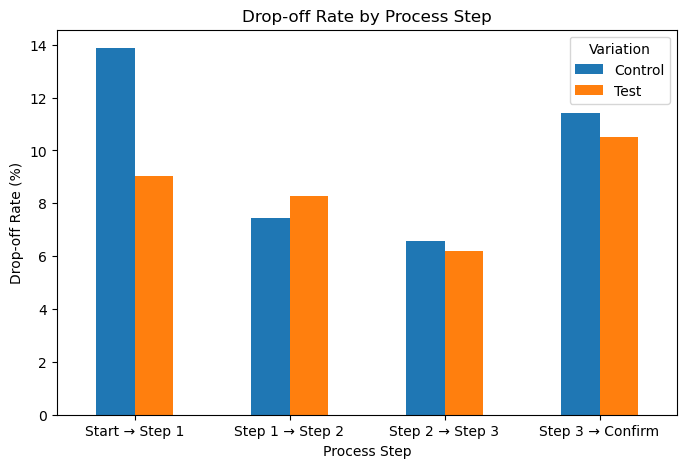

In [ ]:
dropoff_rates.T.plot(kind="bar", figsize=(8,5))

plt.title("Drop-off Rate by Process Step")
plt.xlabel("Process Step")
plt.ylabel("Drop-off Rate (%)")
plt.xticks(rotation=0)
plt.legend(title="Variation")
plt.show()

In [ ]:
## The Test group achieved lower drop-off rates in three of the four process transitions, indicating that the redesigned interface 
# generally helped clients progress through the online process more smoothly. 
# The largest improvement occurred between Start and Step 1, where the drop-off rate decreased from 13.87% in the Control group to 9.04% 
# in the Test group. The only stage where the Test group experienced a slightly higher drop-off was Step 1 to Step 2 (8.28% vs. 7.45%), 
# suggesting that this part of the redesigned interface may still require refinement.

In [ ]:
## 5. Median Completion Time 

In [ ]:
starts = (
    df_footprint_experiment[df_footprint_experiment["process_step"] == "start"]
    .groupby(["client_id", "visit_id"])["date_time"]
    .min()
)

In [ ]:
confirms = (
    df_footprint_experiment[df_footprint_experiment["process_step"] == "confirm"]
    .groupby(["client_id", "visit_id"])["date_time"]
    .max()
)

In [ ]:
starts = starts.rename("start_time").reset_index()
confirms = confirms.rename("confirm_time").reset_index()

completion_new = starts.merge(confirms, on="client_id", how="inner")

In [ ]:
# Earliest start within each visit
starts = (
    df_footprint_experiment[df_footprint_experiment["process_step"] == "start"]
    .groupby(["client_id", "visit_id", "Variation"], as_index=False)["date_time"]
    .min()
    .rename(columns={"date_time": "start_time"})
)

# Latest confirm within each visit
confirms = (
    df_footprint_experiment[df_footprint_experiment["process_step"] == "confirm"]
    .groupby(["client_id", "visit_id", "Variation"], as_index=False)["date_time"]
    .max()
    .rename(columns={"date_time": "confirm_time"})
)

# Merge completed visits
completion_new = starts.merge(
    confirms,
    on=["client_id", "visit_id", "Variation"],
    how="inner"
)

# Calculate completion time
completion_new["completion_time"] = (
    pd.to_datetime(completion_new["confirm_time"]) -
    pd.to_datetime(completion_new["start_time"])
)

# Convert to minutes
completion_new["completion_minutes"] = (
    completion_new["completion_time"].dt.total_seconds() / 60
)

# KPI
completion_new.groupby("Variation")["completion_minutes"].median().round(2)

Variation
Control    4.57
Test       4.18
Name: completion_minutes, dtype: float64

In [ ]:
time_difference = round(4.57 - 4.18, 2)
percent_improvement = round((time_difference / 4.57) * 100, 2)

print(time_difference)
print(percent_improvement)

0.39
8.53


In [ ]:
# The redesigned interface reduced the median completion time from 4.57 minutes in the Control group to 4.18 minutes 
# in the Test group, representing an 8.5% improvement. This suggests that users were able to complete the process more efficiently, 
# indicating that the new interface simplified navigation and reduced the time required to finish the workflow.

In [ ]:
## Hypothesis Testing
#-------------------------------------------------------------------------
# to make data-driven conclusions about the effectiveness of the redesign.
# Answering question: confirmed if the difference in completion rate of the the new design and the old design is statistically significant.
# first, getting count of completions per group

counts = completed.groupby("Variation")["completed"].sum()
counts

Variation
Control    16039
Test       21725
Name: completed, dtype: int64

In [ ]:
# Getting total visits per group
totals = completed.groupby("Variation")["completed"].count()
totals

Variation
Control    32181
Test       37122
Name: completed, dtype: int64

In [ ]:
# Pull out the four specific numbers
count_test = counts["Test"]
count_control = counts["Control"]
nobs_test = totals["Test"]
nobs_control = totals["Control"]

print(count_test, count_control, nobs_test, nobs_control)

21725 16039 37122 32181


In [ ]:
# importing statsmodels for testing
from statsmodels.stats.proportion import proportions_ztest

In [ ]:
# taking two arrays (one for counts and one for totals) and comparing them
count = [count_test, count_control]
nobs = [nobs_test, nobs_control]

z_stat, p_value = proportions_ztest(count, nobs, alternative='larger')

print(z_stat, p_value)

22.89350661920664 2.696237561375928e-116


In [ ]:
# Hypothesis Test: Completion Rate Significance
# ----------------------------------------------------------------
# H0: Test completion rate = Control completion rate (no real difference)
# H1: Test completion rate > Control completion rate (one-tailed)
# Significance level: alpha = 0.05
#
# RESULTS:
#   z-statistic: 22.89
#   p-value: 2.70e-116
#
# DECISION:
#   p-value << alpha (0.05), therefore we REJECT the null hypothesis.
#
# INTERPRETATION:
#   The observed increase in completion rate for the Test group is 
#   statistically significant at the 5% significance level. This is 
#   an extremely strong result (p-value is effectively zero), meaning 
#   it is highly unlikely this difference occurred by random chance.
#   The new design's higher completion rate reflects a genuine effect, 
#   not sampling noise.

In [ ]:
# Cost-Effectiveness Threshold Check
# ----------------------------------------------------------------
completion_rate_test = completed[completed["Variation"] == "Test"]["completed"].mean()
completion_rate_control = completed[completed["Variation"] == "Control"]["completed"].mean()

observed_increase = (completion_rate_test - completion_rate_control) * 100
threshold = 5

print(f"Observed increase: {observed_increase:.2f} percentage points")
print(f"Meets 5% threshold: {observed_increase >= threshold}")

Observed increase: 8.68 percentage points
Meets 5% threshold: True


In [ ]:
# KPI: Cost-Effectiveness Threshold
# ----------------------------------------------------------------
# Vanguard requires a minimum 5 percentage point increase in completion 
# rate for the new design to be considered cost-effective.
#
# RESULTS:
#   Observed increase: 8.68 percentage points (Control 49.84% -> Test 58.52%)
#   Threshold: 5.00 percentage points
#   Worth noting: we interpreted the ambiguity of 5% threshold as 5 percentage points, 
#   consistent with standard framing for completion rate thresholds. 

# DECISION:
#   Observed increase EXCEEDS the 5% threshold.
#
# INTERPRETATION:
#   Beyond being statistically significant, the completion rate 
#   improvement is also large enough to be considered cost-effective 
#   by Vanguard's own criteria. The new design clears the bar by 
#   roughly 3.7 percentage points, suggesting the projected benefits 
#   (engagement, revenue) likely outweigh implementation costs 
#   (design, development, training, disruption).
# --- the new design isn't just technically better, it's better by a wide enough margin
#     to justify the redesign costs, and that margin isn't a fluke.

In [ ]:
## Hypotheses for Time Spent On Each Step:
#-----------------------------------------------------------
# H₀: Average confirm step duration is the same for Test and Control (no real difference)
# H₁: Average confirm step duration is longer for Test than Control (one-tailed)

# Pulling out the two groups' time values to start

confirm_times = df_sorted[df_sorted["step_time_belongs_to"] == "confirm"].copy()
confirm_times["time_spent_seconds"] = confirm_times["time_spent"].dt.total_seconds()

test_times = confirm_times[confirm_times["Variation"] == "Test"]["time_spent_seconds"].dropna()
control_times = confirm_times[confirm_times["Variation"] == "Control"]["time_spent_seconds"].dropna()

In [ ]:
# Running t-test
from scipy.stats import ttest_ind

t_stat, p_value = ttest_ind(test_times, control_times, alternative='greater', equal_var=False)
print(t_stat, p_value)

4.621953871968609 1.9661537518925563e-06


In [ ]:
# Hypothesis Test: Confirm Step Duration
# ----------------------------------------------------------------
# H0: Average time spent on "confirm" step is equal for Test and Control
# H1: Average time spent on "confirm" step is GREATER for Test than Control (one-tailed)
# Significance level: alpha = 0.05
#
# RESULTS:
#   t-statistic: 4.62
#   p-value: 1.97e-06
#
# DECISION:
#   p-value << alpha (0.05), therefore we REJECT the null hypothesis.
#
# INTERPRETATION:
#   Test users spend significantly more time on the confirm step 
#   compared to Control. This is statistically significant, not 
#   random variation. Combined with the completion rate findings, 
#   this suggests the new design trades a bit of speed on certain 
#   steps (particularly confirm) for a meaningfully higher overall 
#   completion rate — supporting the theory that added in-context 
#   guidance may slow down specific steps while improving outcomes.

In [ ]:
# Significant difference between age? 

In [ ]:
df_clients.groupby(["Variation"])["clnt_age"].mean().round(2)

Variation
Control    47.50
Test       47.16
Name: clnt_age, dtype: float64

In [ ]:
# Select client age by group 

control_age = df_clients[df_clients["Variation"] == "Control"]["clnt_age"]
test_age = df_clients[df_clients["Variation"] == "Test"]["clnt_age"]

In [ ]:
# Run t-test 

# H0: the mean age is the same for both Test and Control groups 
# H1: the mean age is different for Test and Control groups 

from scipy import stats as st

st.ttest_ind(control_age, test_age, equal_var=False)

TtestResult(statistic=np.float64(2.416068061200627), pvalue=np.float64(0.015692719461388685), df=np.float64(49556.715189428134))

In [ ]:
# Obtained a p-value = 0.015692719461388675, is below 0.05 hence rejecting the null hyphotesis. 
# The difference in age between both groups is statistically significant. 

# Implication: the ideal A/B test, test and control groups should have similar characterisitcs including age, gender, tenuer etc. 
# If age differs significantly, it suggests the groups are not perfectly balanced. 
# Although the differenec inmean age is statistically significamt, it is very small in magnitude,
#   control = 47.5
#   test  =  47.16 
# the large sample size likely contributed to the signicant p-value. 
# It's probably negligible in practice. 


In [ ]:
df_footprint2.head()

In [ ]:
# Significant difference between tenuere? 

In [ ]:
df_clients.groupby(["Variation"])["clnt_tenure_mnth"].mean().round(2)

Variation
Control    151.06
Test       149.85
Name: clnt_tenure_mnth, dtype: float64

In [ ]:
# Select client tenue in months by group 

control_tenue = df_clients[df_clients["Variation"] == "Control"]["clnt_tenure_mnth"]
test_tenue = df_clients[df_clients["Variation"] == "Test"]["clnt_tenure_mnth"]

In [ ]:
# Run t-test 

# H0: the mean tenue is the same for both Test and Control groups 
# H1: the mean tenue is different for Test and Control groups 

st.ttest_ind(control_tenue, test_tenue, equal_var=False)

TtestResult(statistic=np.float64(1.653522759090036), pvalue=np.float64(0.0982308583662452), df=np.float64(49506.57030914563))

In [ ]:
# Obtained a p-value = 0.09823085836624516 hence we fail to reject the null hypothesis. 
# Not enough evidence to conclude there is significant difference between tenue in both groups 


In [ ]:
# Hypothesis Test: Drop Off Rate

In [ ]:
from statsmodels.stats.proportion import proportions_ztest

# 1. Drop offs on Start → Step 1

# Control: 23391 -> 20146
# Test: 26672 -> 24260

z_stat, p_value = proportions_ztest(
    count=[23391 - 20146, 26672 - 24260],
    nobs=[23391, 26672],
    alternative="larger"
)

print("Start → Step 1")
print("z-statistic:", z_stat)
print("p-value:", p_value)

# -----------------------------------

# 2. Drop offs on Step 1 → Step 2

# Control: 20146 -> 18644
# Test: 24260 -> 22252

z_stat, p_value = proportions_ztest(
    count=[20146 - 18644, 24260 - 22252],
    nobs=[20146, 24260],
    alternative="larger"
)

print("-----------------")
print("Step 1 → Step 2")
print("z-statistic:", z_stat)
print("p-value:", p_value)

# -----------------------------------

# 3. Drop offs on Step 2 → Step 3

# Control: 18644 -> 17416
# Test: 22252 -> 20876

z_stat, p_value = proportions_ztest(
    count=[18644 - 17416, 22252 - 20876],
    nobs=[18644, 22252],
    alternative="larger"
)

print("-----------------")
print("Step 2 → Step 3")
print("z-statistic:", z_stat)
print("p-value:", p_value)

# -----------------------------------

# 4. Drop offs on Step 3 → Confirm

# Control: 17416 -> 15428
# Test: 20876 -> 18682

z_stat, p_value = proportions_ztest(
    count=[17416 - 15428, 20876 - 18682],
    nobs=[17416, 20876],
    alternative="larger"
)

print("-----------------")
print("Step 3 → Confirm")
print("z-statistic:", z_stat)
print("p-value:", p_value)


Start → Step 1
z-statistic: 17.029965850569017
p-value: 2.461647334475853e-65
-----------------
Step 1 → Step 2
z-statistic: -3.1939970650597362
p-value: 0.9992984122806571
-----------------
Step 2 → Step 3
z-statistic: 1.661764051117009
p-value: 0.04828004640980334
-----------------
Step 3 → Confirm
z-statistic: 2.8276306213898215
p-value: 0.0023446940072138255


In [ ]:
# Hypothesis Test: Drop-off Rate by Process Step
# ----------------------------------------------------------------
# H0: The drop-off rate is the same for the Test and Control groups
#     at each transition in the process.
#
# H1: The drop-off rate is lower for the Test group than for the
#     Control group.
#
# Significance level: alpha = 0.05
#
# RESULTS:
#   Start → Step 1
#       z-statistic: 17.03
#       p-value: 2.46e-65
#
#   Step 1 → Step 2
#       z-statistic: -3.19
#       p-value: 0.9993
#
#   Step 2 → Step 3
#       z-statistic: 1.66
#       p-value: 0.0483
#
#   Step 3 → Confirm
#       z-statistic: 2.83
#       p-value: 0.0023
#
# DECISION:
#   Reject H0 for Start → Step 1, Step 2 → Step 3, and
#   Step 3 → Confirm, as the p-values are below 0.05.
#   Fail to reject H0 for Step 1 → Step 2.
#
# INTERPRETATION:
#   The redesigned interface significantly reduced user drop-off
#   during the Start → Step 1, Step 2 → Step 3, and Step 3 → Confirm
#   transitions. However, the Test group experienced a significantly
#   higher drop-off rate between Step 1 → Step 2, indicating that
#   this stage of the redesigned process may introduce additional
#   friction for users.
#
#   Overall, the results indicate that the new design improves user
#   retention at most stages of the process, contributing to the
#   higher overall completion rate observed in the A/B test.
#   However, the increased drop-off between Step 1 and Step 2
#   suggests an opportunity for further optimization. Vanguard
#   should investigate this stage to identify potential usability
#   issues, confusing instructions, or unnecessary friction that
#   may be causing users to abandon the process.

In [ ]:
# Hypothesis Test: Median Completion Time

In [ ]:
control_completion = completion_new[
    completion_new["Variation"] == "Control"
]["completion_minutes"]

test_completion = completion_new[
    completion_new["Variation"] == "Test"
]["completion_minutes"]


from scipy.stats import mannwhitneyu
u_stat, p_value = mannwhitneyu(
    control_completion,
    test_completion,
    alternative="greater"
)

print("U-statistic:", u_stat)
print("p-value:", p_value)


U-statistic: 142326742.5
p-value: 3.982821685397094e-22


In [ ]:
# Hypothesis Test: Median Completion Time
# ----------------------------------------------------------------
# H0: The completion time distribution is the same for the Test
#     and Control groups.
#
# H1: The Test group has lower completion times than the
#     Control group.
#
# Significance level: alpha = 0.05
#
# RESULTS:
#   Median completion time:
#       Control: 4.57 minutes
#       Test:    4.18 minutes
#
#   U-statistic: 142326742.5
#   p-value: 3.98e-22
#
# DECISION:
#   p-value << alpha (0.05), therefore we REJECT the null hypothesis.
#
# INTERPRETATION:
#   The Test group completed the process significantly faster
#   than the Control group, with a median completion time of
#   4.18 minutes compared to 4.57 minutes. The Mann–Whitney U
#   test confirms that this difference is statistically
#   significant and unlikely to be due to random variation.
#   These findings suggest that the redesigned interface not
#   only increases completion rates but also improves the
#   efficiency of the overall user journey for the typical user.

<Axes: xlabel='clnt_age', ylabel='Density'>

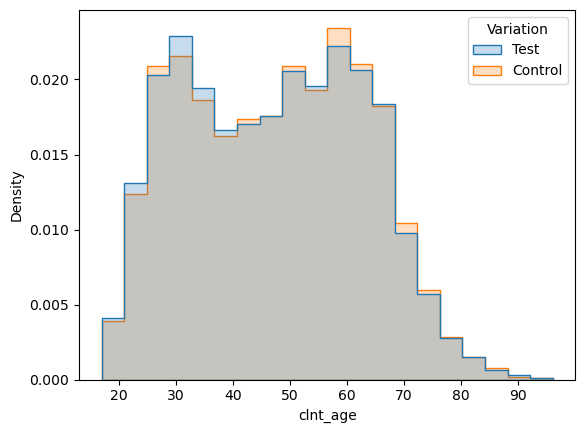

In [ ]:
sns.histplot(
    data=df_clients,
    x="clnt_age",
    hue="Variation",
    bins=20,
    element="step",
    stat="density",
    common_norm=False
)

In [ ]:
## Duration:

- statistically significant samples
- both groups very similar
- could be influenced by seasonality but the samples were still big enough

For Duration Assessment (if we want to add?): The experiment ran from March 15 to June 20, 2017, a window that overlaps significantly with the U.S. tax season (through mid-April). This timing is a limitation worth noting: clients interacting with the platform during this period may behave differently than they would during a typical quarter — for example, being more motivated to complete tasks despite UI friction due to tax-related deadlines, or conversely, more rushed and prone to errors. Since both the Test and Control groups experienced this same seasonal window, the comparison between them likely remains valid — the tax-season effect, if present, would apply equally to both groups. However, this does raise a question about whether the observed 8.7 percentage point improvement in completion rate would generalize to other times of year without this seasonal urgency. We recommend Vanguard validate these findings by extending or re-running the experiment across a different time period (e.g., outside tax season) to confirm the redesign's effectiveness holds under typical, non-seasonal conditions.
[10:04]And one more for Duration Assessment: Beyond seasonality, the large sample sizes achieved within this 3-month window (32,181 Control visits and 37,122 Test visits) suggest the experiment ran long enough to reach statistically robust conclusions — as reflected in the extremely low p-values across our hypothesis tests. However, 3 months may not fully capture clients with longer engagement cycles, such as those who log in quarterly or annually, meaning some client segments may be underrepresented in this dataset.

## Additional data needs:

device type (mobile/desktop)
browser and operating system/version
survey + user feedback on survey responses 
the exact date of customer calls to see if they happened before or after the test Call-rate KPI limitation note is exactly this category: "can't be sure calls were caused by the new process unless the data records call dates."

Age: 47.50 vs 47.16 (statistically significant, p=0.0157)
Tenure: 151.06 vs 149.85 months (not significant, p=0.098)
Design Effectiveness Assessment: To evaluate whether the A/B test was well-designed, we checked whether the Test and Control groups were balanced on key client characteristics. Tenure showed no statistically significant difference (p = 0.098), indicating good balance. Age showed a statistically significant difference (p = 0.0157), but the actual gap was extremely small — 47.50 years vs. 47.16 years — a difference unlikely to meaningfully affect client behavior. This is a common pattern with large sample sizes: even trivial differences can register as 'significant' due to high statistical power. Overall, we conclude the randomization was effective, and the observed completion rate improvements are unlikely to be explained by underlying demographic imbalance between groups.

In [ ]:
## Duration Assessment
#-------------------------------------------
## The A/B experiment ran from **March 15 to June 20, 2017** (approximately three months), providing a sufficiently long observation period to evaluate user behavior.

### Sample Size and Statistical Power

## The experiment included large samples in both groups:

##  - **Control:** 32,181 visits
##  - **Test:** 37,122 visits

##  These sample sizes were large enough to produce statistically robust results, as reflected by the extremely low p-values obtained across the hypothesis tests. Overall, the experiment duration appears sufficient to detect meaningful differences between the two variants.
#-------------------------------------------
### Group Balance

## To assess whether the experiment was well designed, we compared the baseline characteristics of the Test and Control groups.

## Although age showed statistical significance, the actual difference between groups was extremely small and is unlikely to have affected user behavior. This is a common consequence of large sample sizes, where even negligible differences can become statistically significant.

## Overall, the randomization appears effective, and the observed improvements in completion rates are unlikely to be explained by demographic imbalance.

#-------------------------------------------
### Seasonality

## One limitation of the experiment is that it overlapped with the U.S. tax season. During this period, users may behave differently than they would during a typical quarter. For example, they may be more motivated to complete tasks because of tax-related deadlines or, conversely, more rushed and prone to making errors.

## Since both the Test and Control groups were exposed to the same seasonal conditions, the comparison between them remains internally valid. However, it is unclear whether the observed **8.7 percentage point increase in completion rate** would generalize to other times of the year.

## We recommend validating these findings by repeating the experiment outside the tax season to confirm that the redesign remains effective under normal conditions.

#-------------------------------------------
### Long-Term Representation

## Although the experiment lasted three months, it may not fully capture the behavior of clients who interact with the platform less frequently (e.g., quarterly or annually). These user segments may therefore be underrepresented in the dataset.

#-------------------------------------------

## Additional Data Needed

## While the available dataset was sufficient to evaluate completion rates and user behavior, additional information would strengthen the analysis and provide greater insight into the results.

### Device Information

## - Device type (mobile, tablet, desktop)
## - Browser
## - Operating system and version

## This information would help determine whether the redesign performs differently across devices or technical environments.
#-------------------------------------------
### User Feedback

## - Post-session survey responses
## - Qualitative user feedback

## Behavioral metrics show what users did, but direct feedback would help explain **why** they behaved that way and identify usability issues.
#-------------------------------------------
### Customer Support Data

## The dataset indicates whether a client contacted customer support but does not include the **date or timestamp of the call.

## Without this information, it is impossible to determine whether support calls:
## - occurred before the experiment,
## - were triggered by the redesigned process,
## - or were unrelated to the A/B test.

## Including call timestamps would allow a more accurate assessment of the redesign's impact on customer support demand.